# ARCFRESH — Gate Analysis Notebook

Self-contained **raw gate NetCDF** files (one per gate, daily axis 2002–2023).

**Data stack in each gate file:**
| Variable | Source | Temporal | Spatial |
|---|---|---|---|
| `ugos`, `vgos` | CMEMS L4 DUACS | Daily | 0.125° remapped to gate points |
| `err_ugosa`, `err_vgosa` | CMEMS L4 formal mapping error | Daily | 0.125° remapped |
| `sss`, `sss_random_error` | ESA CCI SSS v5.5 | Monthly (1+15 aggregated) mapped to daily | remapped along gate |
| `psal_isas_surface` | ISAS climatology (PSAL z0) | Monthly climatology mapped to daily | remapped along gate |
| `depth` | GEBCO 2025 | Static | gate points |
| `dx`, `x_km`, `longitude`, `latitude` | Gate geometry | Static | gate points |

## Physics convention used here (new local method)
For each gate point `i`, the local tangent is computed from neighboring coordinates and converted into a local normal toward Arctic side:

`v⊥(i,t) = ugos(i,t) * u_into_local(i) + vgos(i,t) * v_into_local(i)`

- `ugos`: eastward positive
- `vgos`: northward positive
- `v⊥ > 0`: inflow toward Arctic side of the gate

No `theta` field is read from NetCDF.

In [92]:
# Cell 1 — Packages & helpers (matplotlib)
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import importlib, warnings

warnings.filterwarnings('ignore', 'Mean of empty slice')

# Local utils (reload to pick up any changes)
import utils as _u
importlib.reload(_u)
from utils import (
    load_gate, list_available_gates,
    local_into_arctic_unit_vectors,
    perpendicular_velocity, perpendicular_velocity_uncertainty,
    volume_transport, volume_transport_uncertainty,
    volume_transport_per_point, volume_transport_per_point_uncertainty,
    freshwater_transport, freshwater_transport_uncertainty,
    freshwater_transport_per_point, freshwater_transport_per_point_uncertainty,
    salt_flux, salt_flux_uncertainty,
    salt_flux_per_point, salt_flux_per_point_uncertainty,
    salt_flux_with_salinity, freshwater_transport_with_salinity,
    salinity_coverage_stats,
    monthly_along_gate_profile,
    SVERDRUP, DEPTH_CAP, MONTH_NAMES, S_REF as S_REF_DEFAULT,
)

# ── Shared plot helpers ──
def plot_monthly_grid(x_km, profiles, y_label, color, title, zero_line=True):
    """4×3 monthly climatology grid (matplotlib)."""
    fig, axes = plt.subplots(4, 3, figsize=(14, 12), sharex=True, sharey=True)
    for m in range(1, 13):
        ax = axes[(m - 1) // 3, (m - 1) % 3]
        p = profiles[m]
        mean = np.asarray(p['mean'], dtype=float)
        std  = np.asarray(p['std'], dtype=float)
        ok = np.isfinite(mean)
        if np.any(ok):
            ax.fill_between(x_km[ok], mean[ok] - std[ok], mean[ok] + std[ok],
                            color=color, alpha=0.15, label='± std' if m == 1 else None)
            ax.plot(x_km[ok], mean[ok], color=color, lw=1.5)
        if zero_line:
            ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
        ax.set_title(f"{MONTH_NAMES[m-1]} (n={p['count']})", fontsize=9)
        ax.grid(alpha=0.25)
    for ax in axes[-1]:
        ax.set_xlabel('Along-gate [km]', fontsize=8)
    for ax in axes[:, 0]:
        ax.set_ylabel(y_label, fontsize=8)
    fig.suptitle(title, fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()


def plot_timeseries(time, values, sigma, y_label, title, color, stats_text, mean_val):
    """Timeseries with uncertainty band (matplotlib)."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    ok = np.isfinite(values)
    ax.plot(time[ok], values[ok], color=color, lw=1.2, label=y_label)
    ok_band = ok & np.isfinite(sigma)
    if np.any(ok_band):
        ax.fill_between(time[ok_band], values[ok_band] - sigma[ok_band],
                        values[ok_band] + sigma[ok_band],
                        color=color, alpha=0.12, label='±σ uncertainty')
    ax.axhline(mean_val, color=color, lw=1, ls='--', alpha=0.7)
    ax.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax.text(0.01, 0.97, stats_text, transform=ax.transAxes, fontsize=8,
            va='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
    ax.set_ylabel(y_label); ax.set_xlabel('Time')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.9); ax.grid(alpha=0.25)
    fig.tight_layout(); plt.show()


print('✅ Ready (matplotlib + local per-point projection)')

✅ Ready (matplotlib + local per-point projection)


In [93]:
# Cell 2 — List available NetCDF files
PRIMARY_NC_DIR = Path('/Users/nicolocaron/Desktop/ARCFRESH/NETCDF CODE')
FALLBACK_NC_DIR = Path('../data/netcdf')

if PRIMARY_NC_DIR.exists():
    NC_DIR = PRIMARY_NC_DIR
elif FALLBACK_NC_DIR.exists():
    NC_DIR = FALLBACK_NC_DIR
else:
    raise FileNotFoundError('No NetCDF directory found (checked PRIMARY_NC_DIR and FALLBACK_NC_DIR).')

print(f'Using NC_DIR = {NC_DIR}')
for f in list_available_gates(NC_DIR):
    size_mb = (NC_DIR / f).stat().st_size / 1e6
    print(f'  {f}  ({size_mb:.1f} MB)')

Using NC_DIR = /Users/nicolocaron/Desktop/ARCFRESH/NETCDF CODE
  arcfresh_barents_opening_2002-2023.nc  (12.5 MB)
  arcfresh_barents_sea_cao_2002-2023.nc  (21.6 MB)
  arcfresh_barents_sea_kara_sea_2002-2023.nc  (3.7 MB)
  arcfresh_beaufort_sea_caa_2002-2023.nc  (4.2 MB)
  arcfresh_beaufort_sea_cao_2002-2023.nc  (22.9 MB)
  arcfresh_bering_strait_2002-2023.nc  (2.2 MB)
  arcfresh_caa_cao_2002-2023.nc  (14.9 MB)
  arcfresh_davis_strait_2002-2023.nc  (6.9 MB)
  arcfresh_denmark_strait_2002-2023.nc  (8.4 MB)
  arcfresh_ess_beaufort_sea_2002-2023.nc  (7.7 MB)
  arcfresh_ess_cao_2002-2002.nc  (8.9 MB)
  arcfresh_ess_cao_2003-2003.nc  (8.8 MB)
  arcfresh_ess_cao_2004-2004.nc  (8.8 MB)
  arcfresh_ess_cao_2005-2005.nc  (8.9 MB)
  arcfresh_ess_cao_2006-2006.nc  (8.8 MB)
  arcfresh_ess_cao_2007-2007.nc  (9.0 MB)
  arcfresh_ess_cao_2008-2008.nc  (9.0 MB)
  arcfresh_ess_cao_2009-2009.nc  (8.8 MB)
  arcfresh_ess_cao_2010-2010.nc  (9.1 MB)
  arcfresh_ess_cao_2011-2011.nc  (9.5 MB)
  arcfresh_ess_cao_

In [94]:
# ══════════════════════════════════════════════════════════════
# INPUTS — change these
# ══════════════════════════════════════════════════════════════
GATE_ID    = 'davis_strait'
DATE_START = '2010-01-01'
DATE_END   = '2023-12-31'
CAP        = 250          # depth cap (m)
S_REF      = 34.8         # reference salinity (PSU)
RHO        = 1024.0       # seawater density (kg/m³)

# ── Load & slice ──
nc_file = NC_DIR / f'arcfresh_{GATE_ID}_2002-2023.nc'
ds = load_gate(nc_file).sel(time=slice(DATE_START, DATE_END))

gate_name = ds.attrs.get('gate_display_name', GATE_ID)
x_km      = ds['x_km'].values
time      = pd.to_datetime(ds['time'].values)

has_cci  = bool(int(ds.attrs.get('has_cci', 0))) and ('sss' in ds)
has_isas = bool(int(ds.attrs.get('has_isas', 0))) and ('psal_isas_surface' in ds)
has_sss  = ('sss' in ds) and bool(np.isfinite(ds['sss'].values).any())

lon = ds['longitude'].values
lat = ds['latitude'].values

print(f'╔══════════════════════════════════════════════════╗')
print(f'  Gate    : {gate_name}')
print(f'  Region  : {ds.attrs.get("region", "—")}')
print(f'  Points  : {ds.dims["point"]}  |  Days: {ds.dims["time"]}')
print(f'  Period  : {str(time[0].date())} → {str(time[-1].date())}')
print(f'  Length  : {x_km[-1]:.1f} km')
print(f'  Lon     : {lon[0]:.2f}° → {lon[-1]:.2f}°')
print(f'  Lat     : {lat[0]:.2f}° → {lat[-1]:.2f}°')
print(f'  Velocity: CMEMS L4 daily 0.125° (DUACS v202411)')
print(f'  Bathy   : GEBCO 2025 (15 arc-sec)')
print(f'  CCI SSS : {"AVAILABLE" if has_cci else "NOT AVAILABLE"}')
print(f'  ISAS z0 : {"AVAILABLE" if has_isas else "NOT AVAILABLE"}')
print(f'  Cap     : {CAP} m  |  S_ref: {S_REF} PSU  |  ρ: {RHO} kg/m³')
print(f'╚══════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════╗
  Gate    : Davis Strait
  Region  : Arctic Ocean (external boundaries)
  Points  : 92  |  Days: 5113
  Period  : 2010-01-01 → 2023-12-31
  Length  : 479.6 km
  Lon     : -64.40° → -52.98°
  Lat     : 67.68° → 68.14°
  Velocity: CMEMS L4 daily 0.125° (DUACS v202411)
  Bathy   : GEBCO 2025 (15 arc-sec)
  CCI SSS : AVAILABLE
  ISAS z0 : AVAILABLE
  Cap     : 250 m  |  S_ref: 34.8 PSU  |  ρ: 1024.0 kg/m³
╚══════════════════════════════════════════════════╝


/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_45947/3926907429.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'  Points  : {ds.dims["point"]}  |  Days: {ds.dims["time"]}')


---
## 1 · Geostrophic Velocity (Local Per-Point Projection)
`v⊥(i,t) = ugos(i,t)·u_into_local(i) + vgos(i,t)·v_into_local(i)` — positive = into Arctic side.

- `ugos`: eastward velocity (CMEMS)
- `vgos`: northward velocity (CMEMS)
- `(u_into_local, v_into_local)`: local gate normal oriented toward Arctic side at each gate point

Plots:
1. **4×3 profile**: monthly climatology, band = temporal std. dev.
2. **Timeseries**: gate-mean `v⊥`, band = formal CMEMS σ

/Users/nicolocaron/Documents/GitHub/arcfresh-gate-physics/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


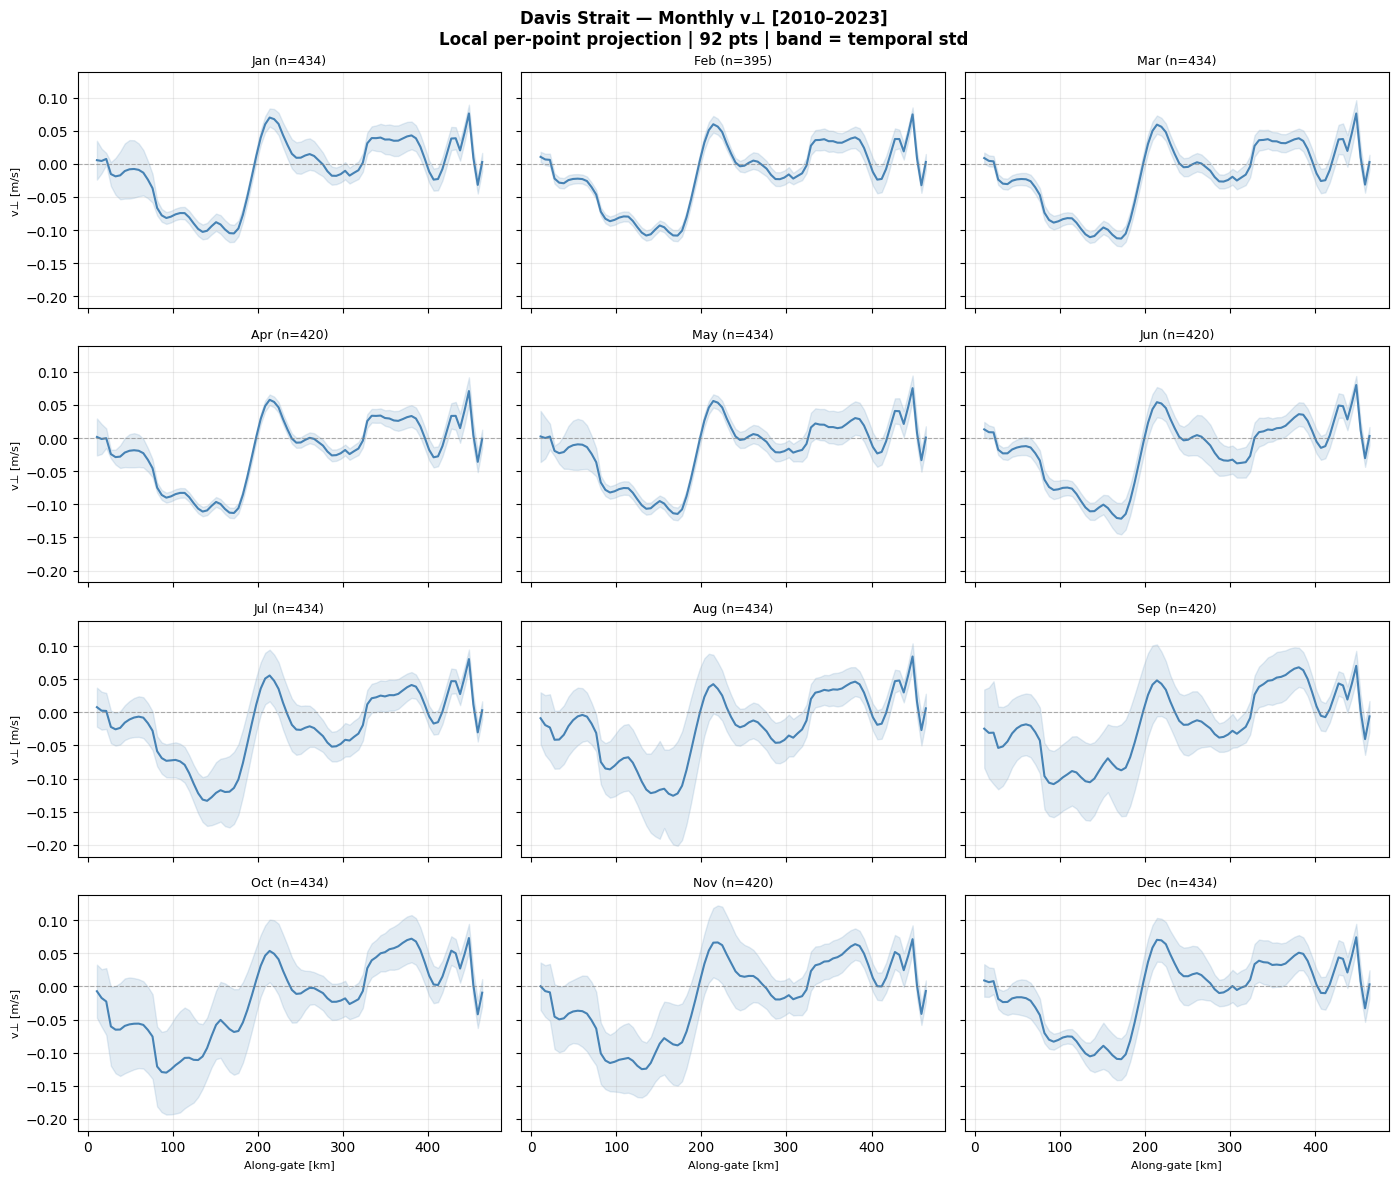

In [95]:
# 1a. v⊥ monthly climatology (4×3 along-gate profile)
v_perp   = perpendicular_velocity(ds)
sigma_vp = perpendicular_velocity_uncertainty(ds)

profiles = monthly_along_gate_profile(v_perp, time, x_km, sigma=sigma_vp)

plot_monthly_grid(
    x_km, profiles, y_label='v⊥ [m/s]', color='steelblue',
    title=f'{gate_name} — Monthly v⊥ [{DATE_START[:4]}–{DATE_END[:4]}]\n'
          f'Local per-point projection | {ds.sizes["point"]} pts | band = temporal std',
)

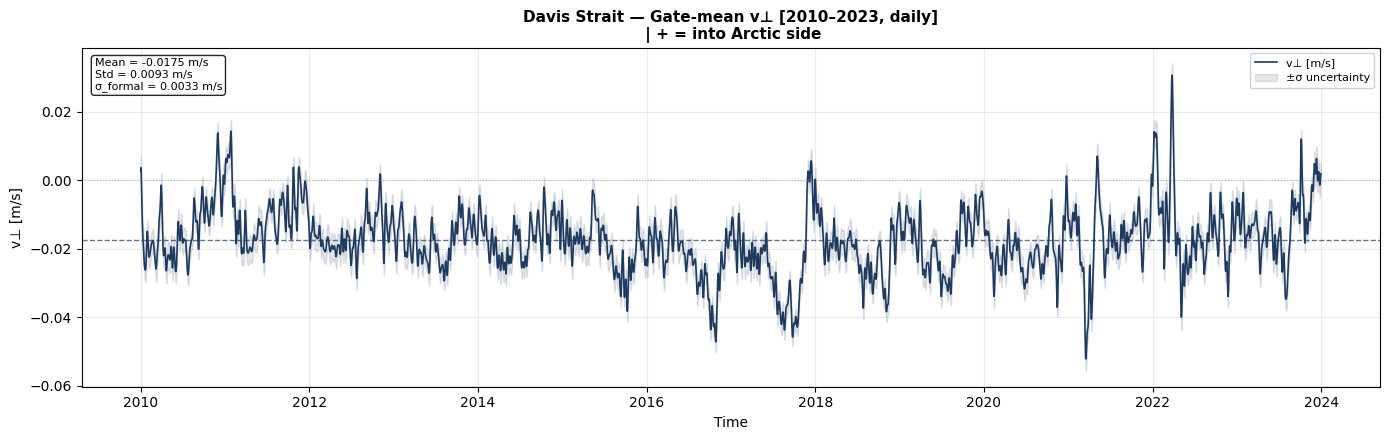

In [96]:
# 1b. v⊥ gate-mean timeseries
vp_mean_ts = np.nanmean(v_perp, axis=0)
N_valid = np.sum(~np.isnan(sigma_vp), axis=0).astype(float)
N_valid[N_valid == 0] = np.nan
sig_vp_mean = np.sqrt(np.nansum(sigma_vp**2, axis=0)) / N_valid

mu_vp = float(np.nanmean(vp_mean_ts))
plot_timeseries(
    time, vp_mean_ts, sig_vp_mean,
    y_label='v⊥ [m/s]', color='#1E3A5F',
    title=f'{gate_name} — Gate-mean v⊥ [{DATE_START[:4]}–{DATE_END[:4]}, daily]\n'
          f' | + = into Arctic side',
    stats_text=f'Mean = {mu_vp:+.4f} m/s\nStd = {np.nanstd(vp_mean_ts):.4f} m/s\n'
               f'σ_formal = {np.nanmean(sig_vp_mean):.4f} m/s',
    mean_val=mu_vp,
)

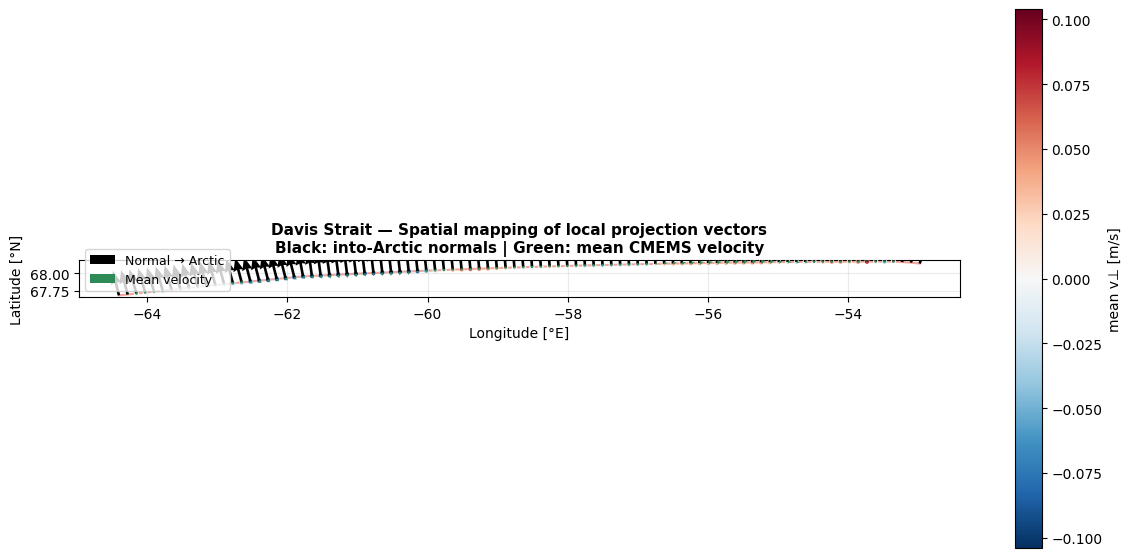

Vector mapping: 92 pts, subsampled every 1 for arrows.


In [97]:
# 1c. Spatial mapping: gate + local normals + mean velocity vectors
u_loc, v_loc = local_into_arctic_unit_vectors(ds)
u_mean = np.nanmean(ds['ugos'].values, axis=1)
v_mean = np.nanmean(ds['vgos'].values, axis=1)
vp_mean = np.nanmean(v_perp, axis=1)

n_pts = len(lon)
step = max(1, n_pts // 80)
idx = np.arange(0, n_pts, step)

fig, ax = plt.subplots(figsize=(12, 8))

# Gate points colored by mean v⊥
vlim = np.nanpercentile(np.abs(vp_mean), 95)
sc = ax.scatter(lon, lat, c=vp_mean, cmap='RdBu_r', vmin=-vlim, vmax=vlim,
                s=12, edgecolors='white', linewidths=0.3, zorder=3)
plt.colorbar(sc, ax=ax, label='mean v⊥ [m/s]', shrink=0.7)

# Gate line
ax.plot(lon, lat, color='#E74C3C', lw=1.5, alpha=0.5, zorder=2)

# Normals (black) and velocity vectors (green) via quiver
scale_norm = 35   # larger = shorter arrows
scale_vel = 25
ax.quiver(lon[idx], lat[idx], u_loc[idx], v_loc[idx],
          color='black', scale=scale_norm, width=0.003, headwidth=4,
          label='Normal → Arctic', zorder=4)
ax.quiver(lon[idx], lat[idx], u_mean[idx], v_mean[idx],
          color='#2E8B57', scale=scale_vel, width=0.003, headwidth=4,
          label='Mean velocity', zorder=4)

ax.set_xlabel('Longitude [°E]'); ax.set_ylabel('Latitude [°N]')
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='lower left')
ax.set_title(f'{gate_name} — Spatial mapping of local projection vectors\n'
             f'Black: into-Arctic normals | Green: mean CMEMS velocity',
             fontsize=11, fontweight='bold')
ax.grid(alpha=0.25)
fig.tight_layout(); plt.show()
print(f'Vector mapping: {n_pts} pts, subsampled every {step} for arrows.')

---
## 2 · Volume Transport
`VT(t) = Σ_i v⊥(i,t) · min(depth(i), cap) · dx(i)` in Sv (10⁶ m³/s), with local per-point `v⊥`.

- **4×3 profile**: per-point VT along gate, band = temporal std. dev.
- **Timeseries**: integrated VT, band = formal CMEMS σ

/Users/nicolocaron/Documents/GitHub/arcfresh-gate-physics/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


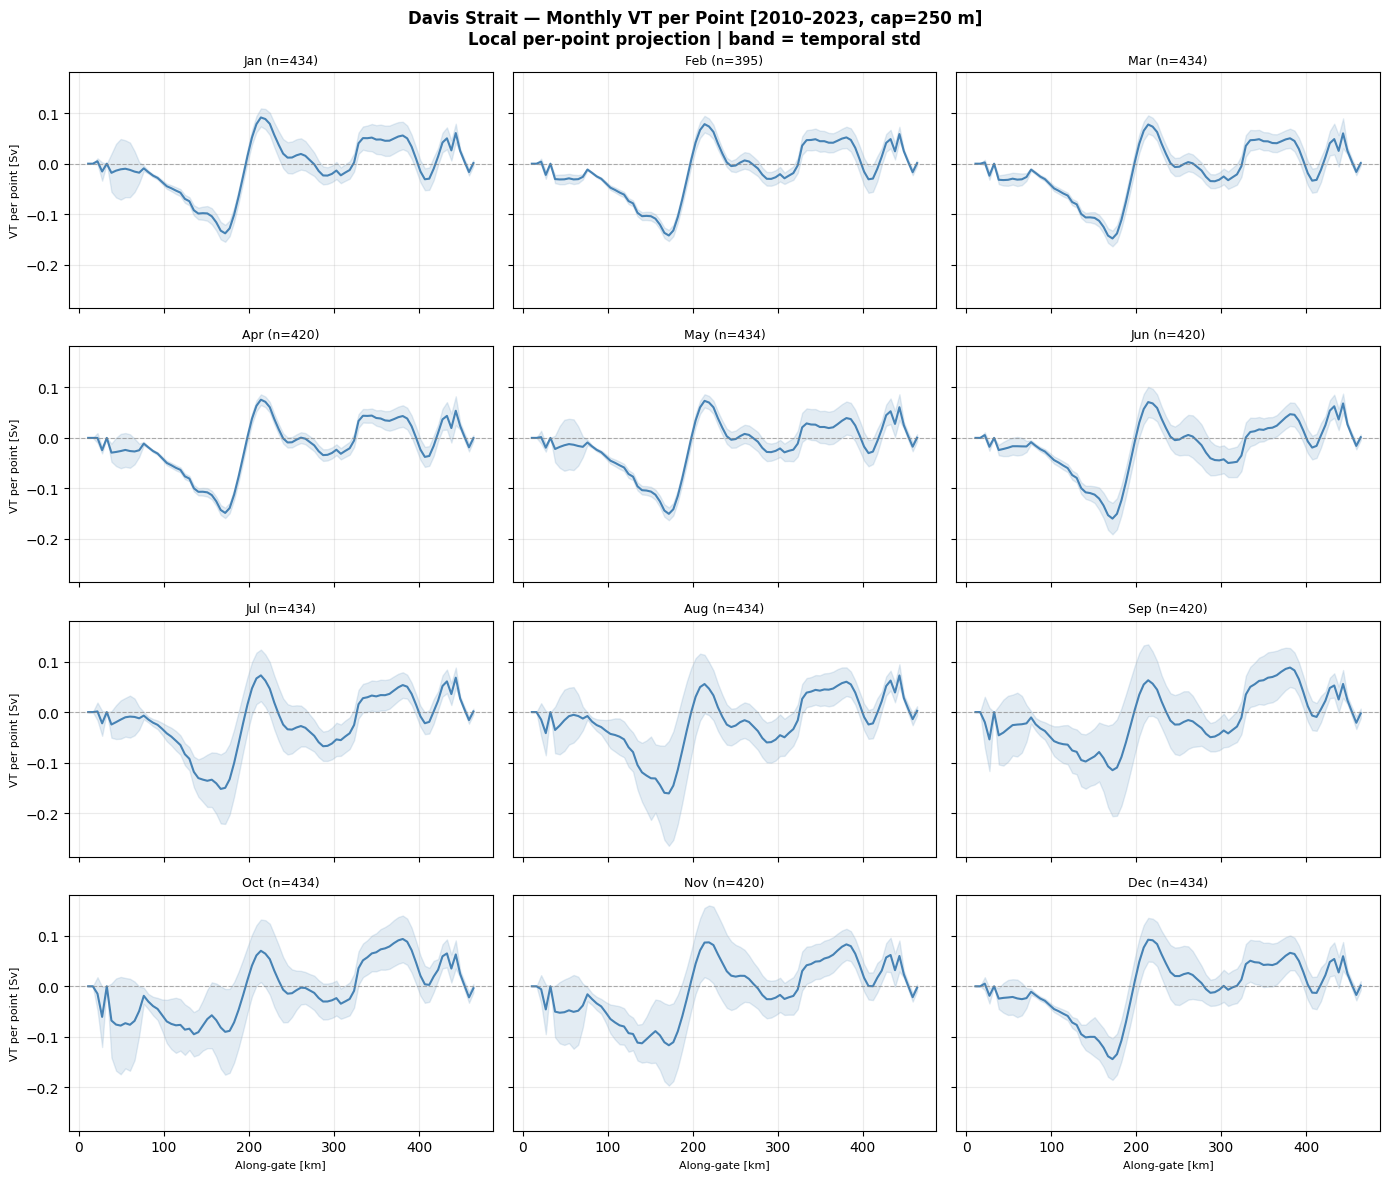

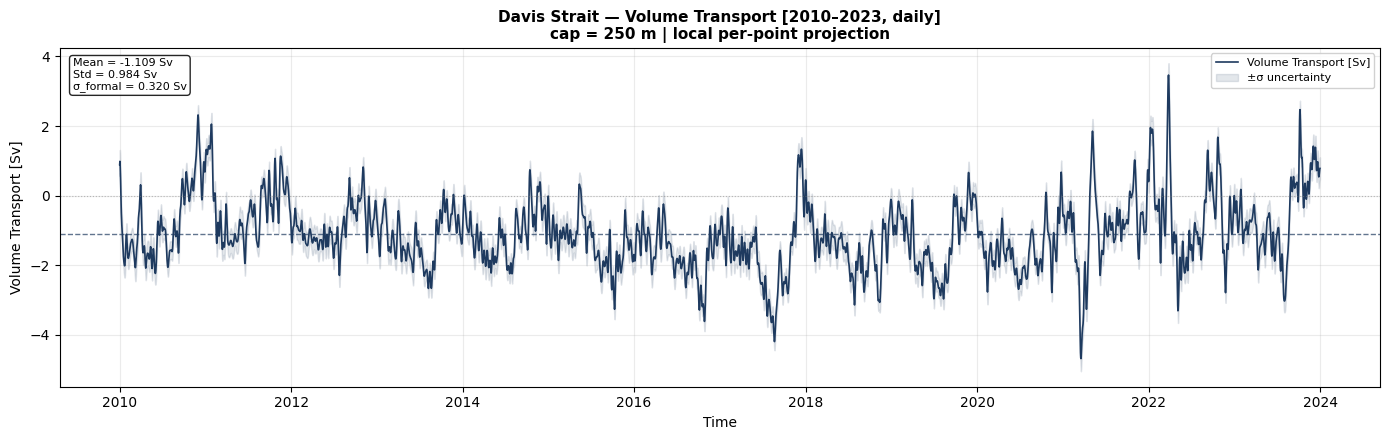

In [98]:
# 2. Volume Transport: 4×3 profile + timeseries
vt_pp       = volume_transport_per_point(ds, depth_cap=CAP)
sigma_vt_pp = volume_transport_per_point_uncertainty(ds, depth_cap=CAP)
vt_profiles = monthly_along_gate_profile(vt_pp, time, x_km, sigma=sigma_vt_pp)

plot_monthly_grid(
    x_km, vt_profiles, y_label='VT per point [Sv]', color='steelblue',
    title=f'{gate_name} — Monthly VT per Point [{DATE_START[:4]}–{DATE_END[:4]}, cap={CAP} m]\n'
          f'Local per-point projection | band = temporal std',
)

# Timeseries
vt_sv, t = volume_transport(ds, depth_cap=CAP)
sigma_vt = volume_transport_uncertainty(ds, depth_cap=CAP)
mean_vt = float(np.nanmean(vt_sv))

plot_timeseries(
    t, vt_sv, sigma_vt,
    y_label='Volume Transport [Sv]', color='#1E3A5F',
    title=f'{gate_name} — Volume Transport [{DATE_START[:4]}–{DATE_END[:4]}, daily]\n'
          f'cap = {CAP} m | local per-point projection',
    stats_text=f'Mean = {mean_vt:+.3f} Sv\nStd = {np.nanstd(vt_sv):.3f} Sv\n'
               f'σ_formal = {np.nanmean(sigma_vt):.3f} Sv',
    mean_val=mean_vt,
)

---
## 3 · Surface Salinity Profile (CCI + ISAS surface)
- `sss`: ESA CCI SSS v5.5 monthly (day 1+15 aggregated) mapped to daily axis
- `psal_isas_surface`: ISAS PSAL first layer climatology mapped to daily axis

Plots:
1. **4×3 profile**: monthly climatology, band = temporal std. dev.
2. **Timeseries**: gate-mean salinity, band = spatial σ

In [99]:
             print(f'⚠️  {label}: all NaN — skip.')
        plot_monthly_grid(
            x_km, sal_profiles, y_label='Salinity [PSU]', color=color,
            title=f'{gate_name} — {label} Monthly zero_line=False,

IndentationError: unexpected indent (875255916.py, line 1)

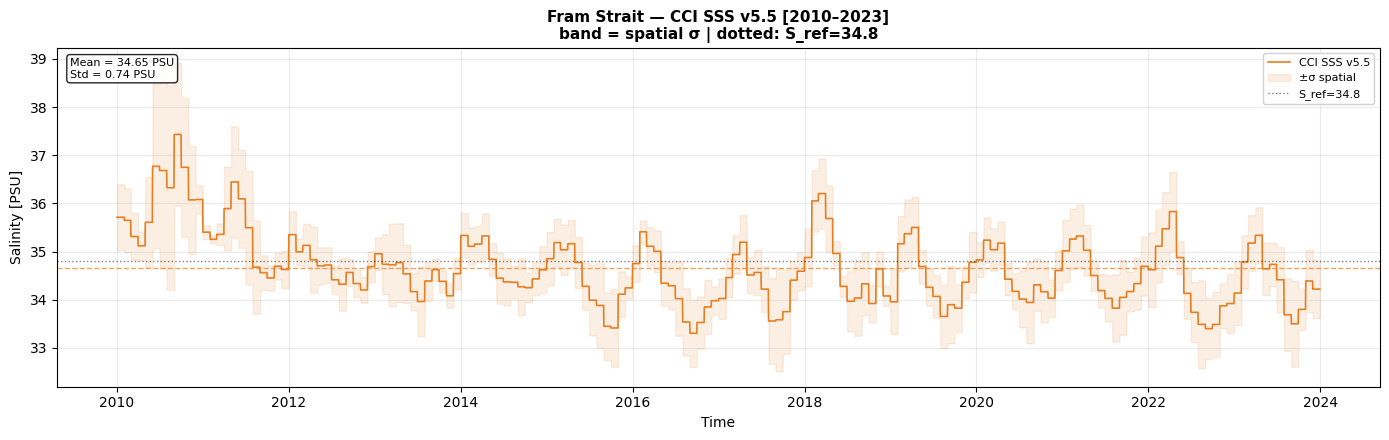

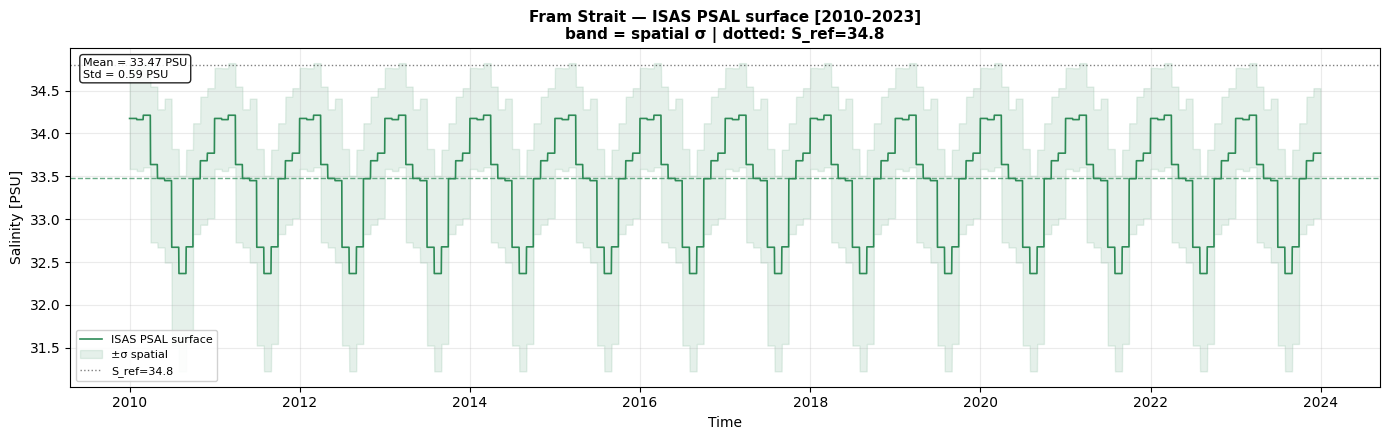

In [ ]:
# 3b. Salinity mean timeseries
sources = []
if has_cci and 'sss' in ds:
    sources.append(('sss', 'CCI SSS v5.5', '#E67E22'))
if has_isas and 'psal_isas_surface' in ds:
    sources.append(('psal_isas_surface', 'ISAS PSAL surface', '#2E8B57'))

if not sources:
    print('⚠️  No salinity source — skip timeseries.')
else:
    for var_name, label, color in sources:
        sal = ds[var_name].values
        if not np.isfinite(sal).any():
            print(f'⚠️  {label}: all NaN — skip.')
            continue

        sal_mean_ts = np.nanmean(sal, axis=0)
        sal_std_ts  = np.nanstd(sal, axis=0)
        mu = float(np.nanmean(sal_mean_ts))

        fig, ax = plt.subplots(figsize=(14, 4.5))
        ok = np.isfinite(sal_mean_ts)
        ax.plot(time[ok], sal_mean_ts[ok], color=color, lw=1.2, label=label)
        ok_band = ok & np.isfinite(sal_std_ts)
        if np.any(ok_band):
            ax.fill_between(time[ok_band],
                            sal_mean_ts[ok_band] - sal_std_ts[ok_band],
                            sal_mean_ts[ok_band] + sal_std_ts[ok_band],
                            color=color, alpha=0.12, label='±σ spatial')
        ax.axhline(mu, color=color, lw=1, ls='--', alpha=0.7)
        ax.axhline(S_REF, color='black', lw=1, ls=':', alpha=0.5, label=f'S_ref={S_REF}')
        ax.text(0.01, 0.97, f'Mean = {mu:.2f} PSU\nStd = {np.nanstd(sal_mean_ts[ok]):.2f} PSU',
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
        ax.set_ylabel('Salinity [PSU]'); ax.set_xlabel('Time')
        ax.set_title(f'{gate_name} — {label} [{DATE_START[:4]}–{DATE_END[:4]}]\n'
                     f'band = spatial σ | dotted: S_ref={S_REF}',
                     fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, framealpha=0.9); ax.grid(alpha=0.25)
        fig.tight_layout(); plt.show()

---
## 4 · Freshwater Transport
`FW(t) = Σ_i v⊥(i,t) · (1 − SSS(i,t)/S_ref) · min(depth(i), cap) · dx(i)` in mSv.

- Uses local per-point `v⊥`
- Uses `sss` (CCI-based field in gate NetCDF)

Plots:
1. **4×3 profile**: per-point FW along gate, band = temporal std. dev.
2. **Timeseries**: integrated FW, band = formal velocity σ propagation

/Users/nicolocaron/Documents/GitHub/arcfresh-gate-physics/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


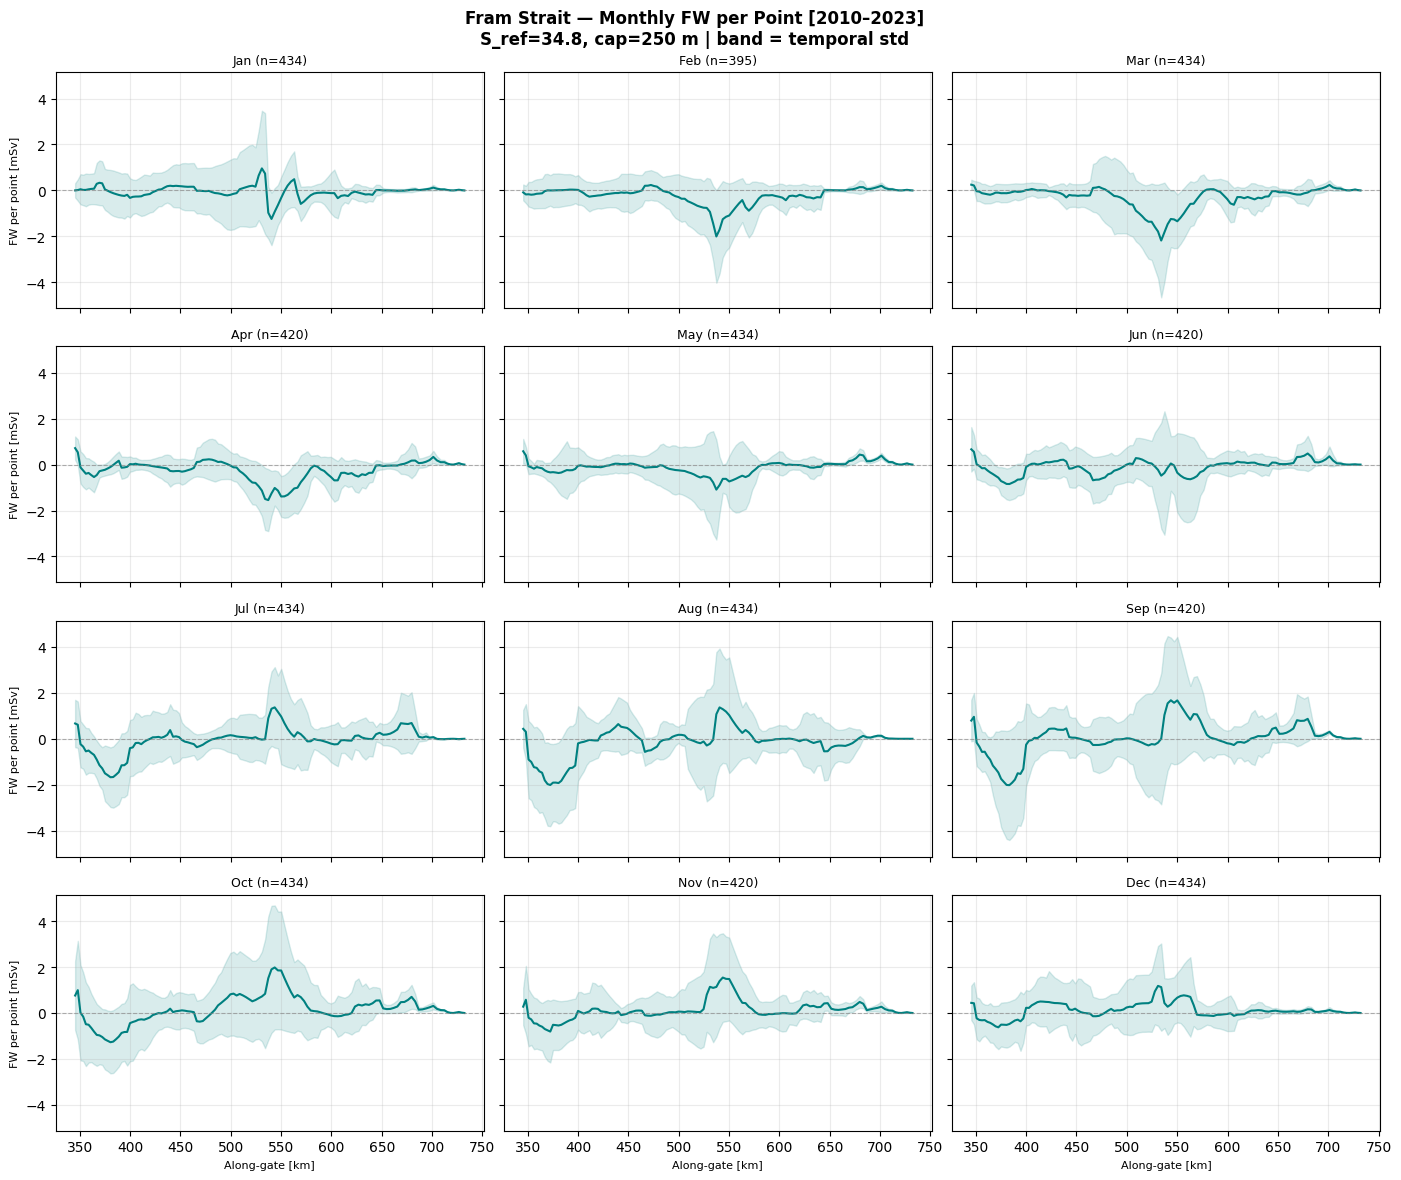

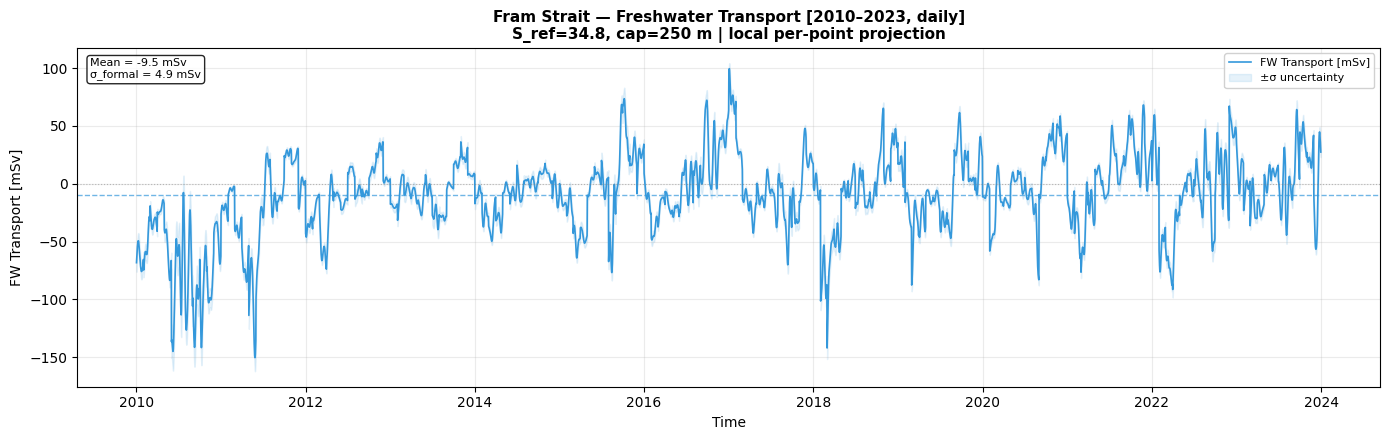

In [ ]:
# 4. Freshwater Transport: 4×3 profile + timeseries
if not has_sss:
    print('⚠️  No finite CCI SSS data — skip freshwater transport.')
else:
    fw_pp       = freshwater_transport_per_point(ds, depth_cap=CAP, s_ref=S_REF)
    sigma_fw_pp = freshwater_transport_per_point_uncertainty(ds, depth_cap=CAP, s_ref=S_REF)
    fw_pp_msv       = fw_pp / 1e3
    sigma_fw_pp_msv = sigma_fw_pp / 1e3

    fw_profiles = monthly_along_gate_profile(fw_pp_msv, time, x_km, sigma=sigma_fw_pp_msv)
    plot_monthly_grid(
        x_km, fw_profiles, y_label='FW per point [mSv]', color='teal',
        title=f'{gate_name} — Monthly FW per Point [{DATE_START[:4]}–{DATE_END[:4]}]\n'
              f'S_ref={S_REF}, cap={CAP} m | band = temporal std',
    )

    fw_m3s, t_fw = freshwater_transport(ds, depth_cap=CAP, s_ref=S_REF)
    sigma_fw     = freshwater_transport_uncertainty(ds, depth_cap=CAP, s_ref=S_REF)
    fw_msv       = fw_m3s / 1e3
    sigma_fw_msv = sigma_fw / 1e3
    mean_fw = float(np.nanmean(fw_msv))

    plot_timeseries(
        t_fw, fw_msv, sigma_fw_msv,
        y_label='FW Transport [mSv]', color='#3498DB',
        title=f'{gate_name} — Freshwater Transport [{DATE_START[:4]}–{DATE_END[:4]}, daily]\n'
              f'S_ref={S_REF}, cap={CAP} m | local per-point projection',
        stats_text=f'Mean = {mean_fw:+.1f} mSv\nσ_formal = {np.nanmean(sigma_fw_msv):.1f} mSv',
        mean_val=mean_fw,
    )

---
## 5 · Salt Flux
`Salt(t) = Σ_i ρ · (SSS(i,t)/1000) · v⊥(i,t) · min(depth(i), cap) · dx(i)` in Gg/s.

- Uses local per-point `v⊥`
- Uses `sss` (CCI-based field in gate NetCDF)

Plots:
1. **4×3 profile**: per-point salt flux along gate, band = temporal std. dev.
2. **Timeseries**: integrated salt flux, band = formal velocity σ propagation

/Users/nicolocaron/Documents/GitHub/arcfresh-gate-physics/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


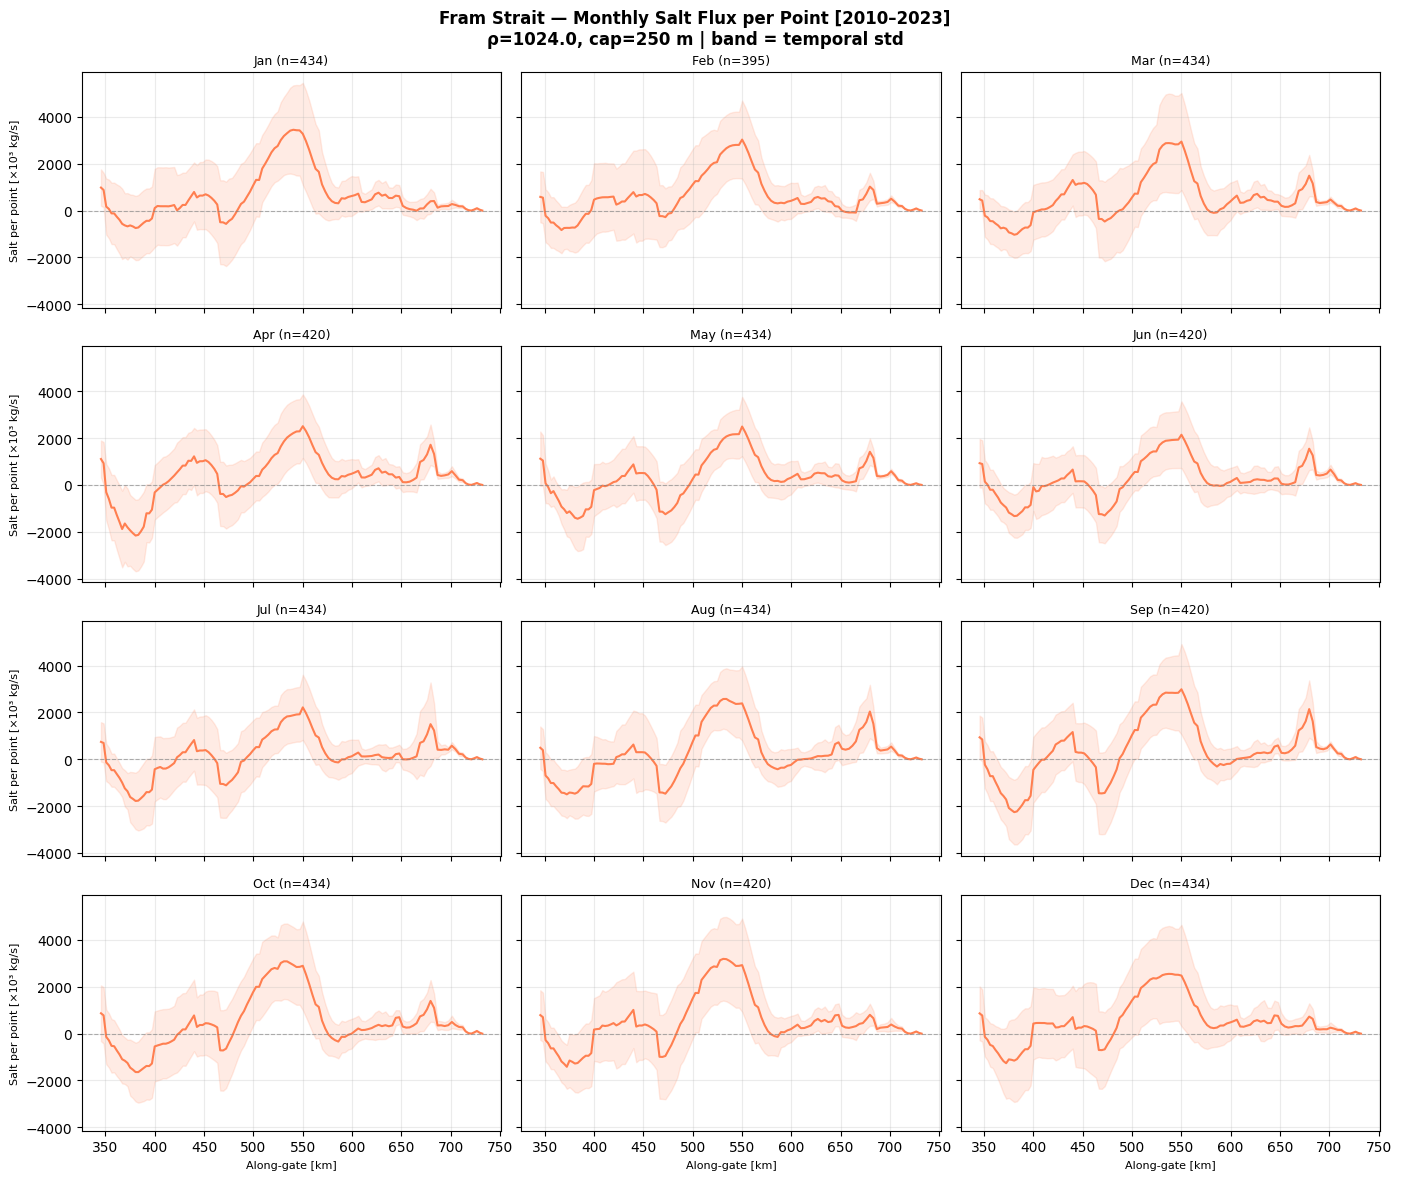

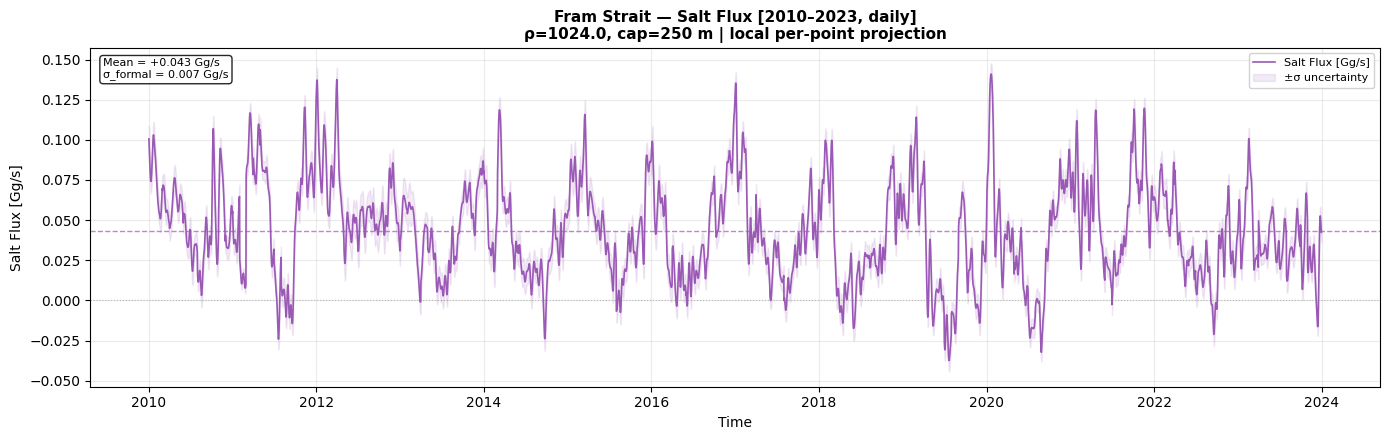

In [ ]:
# 5. Salt Flux: 4×3 profile + timeseries
if not has_sss:
    print('⚠️  No finite CCI SSS data — skip salt flux.')
else:
    sm_pp       = salt_flux_per_point(ds, depth_cap=CAP, rho=RHO)
    sigma_sm_pp = salt_flux_per_point_uncertainty(ds, depth_cap=CAP, rho=RHO)
    sm_pp_kt       = sm_pp / 1e3
    sigma_sm_pp_kt = sigma_sm_pp / 1e3

    sm_profiles = monthly_along_gate_profile(sm_pp_kt, time, x_km, sigma=sigma_sm_pp_kt)
    plot_monthly_grid(
        x_km, sm_profiles, y_label='Salt per point [×10³ kg/s]', color='coral',
        title=f'{gate_name} — Monthly Salt Flux per Point [{DATE_START[:4]}–{DATE_END[:4]}]\n'
              f'ρ={RHO}, cap={CAP} m | band = temporal std',
    )

    sm_kgs, t_sm = salt_flux(ds, depth_cap=CAP, rho=RHO)
    sigma_sm     = salt_flux_uncertainty(ds, depth_cap=CAP, rho=RHO)
    sm_ggs       = sm_kgs / 1e9
    sigma_ggs    = sigma_sm / 1e9
    mean_sm = float(np.nanmean(sm_ggs))

    plot_timeseries(
        t_sm, sm_ggs, sigma_ggs,
        y_label='Salt Flux [Gg/s]', color='#9B59B6',
        title=f'{gate_name} — Salt Flux [{DATE_START[:4]}–{DATE_END[:4]}, daily]\n'
              f'ρ={RHO}, cap={CAP} m | local per-point projection',
        stats_text=f'Mean = {mean_sm:+.3f} Gg/s\nσ_formal = {np.nanmean(sigma_ggs):.3f} Gg/s',
        mean_val=mean_sm,
    )

---
## 6 · CCI vs ISAS Salinity — Source Comparison

**Motivation**: CCI SSS has limited spatial coverage on many Arctic gates (e.g. only ~25 % at Fram Strait),
while ISAS PSAL surface covers ≥ 96 % of points everywhere. This section compares both sources
**independently** (no fallback/hybrid) to inform the choice for Sm / FW transport.

Plots:
1. **Along-track SSS**: 2-panel subplot (CCI vs ISAS), temporal mean ± std, plus spatial coverage stats.
2. **Sm timeline**: integrated salt flux computed separately with CCI and ISAS.
3. **Fw timeline**: integrated freshwater transport computed separately with CCI and ISAS.

/Users/nicolocaron/Documents/GitHub/arcfresh-gate-physics/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


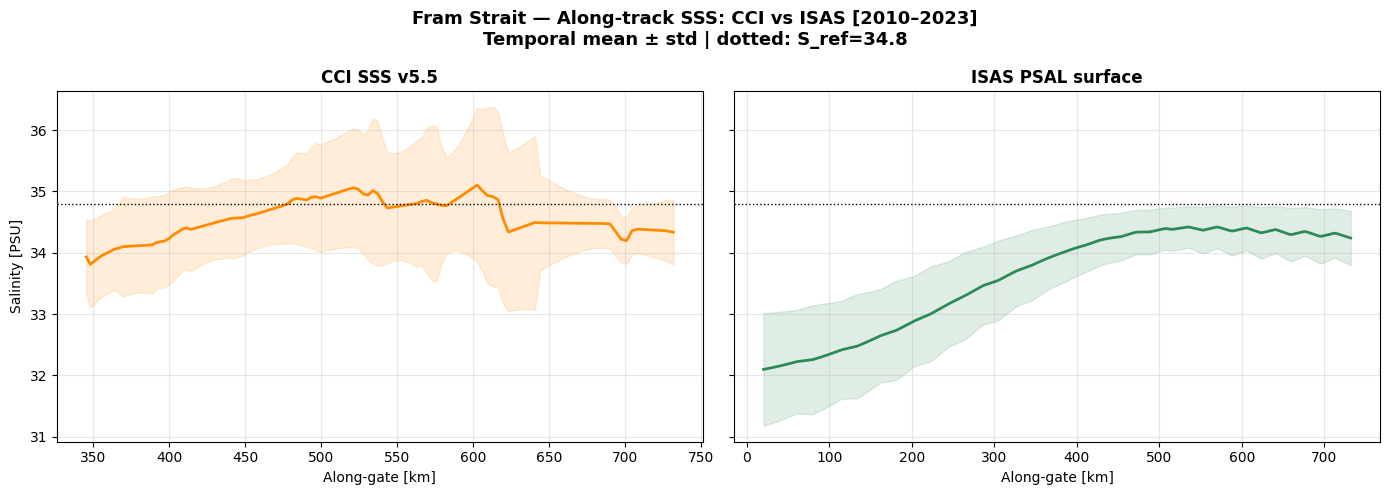


────────────────────────────────────────────────────────────────────────
  Coverage stats — Fram Strait  (2010-01-01 → 2023-12-31), 277 pts
────────────────────────────────────────────────────────────────────────
  CCI SSS v5.5                         data: 125/277  cov:  35.5%  range: [31.15, 40.21]
  ISAS PSAL surface                    data: 267/277  cov:  96.4%  range: [30.55, 34.78]
────────────────────────────────────────────────────────────────────────


In [ ]:
# 6a. Along-track SSS: CCI vs ISAS + coverage stats
SAL_SOURCES = [('sss', 'CCI SSS v5.5', 'darkorange'),
               ('psal_isas_surface', 'ISAS PSAL surface', 'seagreen')]
SAL_SOURCES = [(v, l, c) for v, l, c in SAL_SOURCES if v in ds]

if len(SAL_SOURCES) < 2:
    print(f'⚠️  Need both CCI and ISAS to compare — only {len(SAL_SOURCES)} available.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, (var, label, col) in zip(axes, SAL_SOURCES):
        sal_mean = np.nanmean(ds[var].values, axis=1)
        sal_std  = np.nanstd(ds[var].values, axis=1)
        ok = np.isfinite(sal_mean)
        ax.plot(x_km[ok], sal_mean[ok], color=col, lw=2)
        ax.fill_between(x_km[ok], sal_mean[ok]-sal_std[ok], sal_mean[ok]+sal_std[ok],
                         color=col, alpha=0.15)
        ax.axhline(S_REF, color='k', lw=1, ls=':')
        ax.set_title(label, fontweight='bold'); ax.set_xlabel('Along-gate [km]'); ax.grid(alpha=0.3)
    axes[0].set_ylabel('Salinity [PSU]')
    fig.suptitle(f'{gate_name} — Along-track SSS: CCI vs ISAS [{DATE_START[:4]}–{DATE_END[:4]}]\n'
                 f'Temporal mean ± std | dotted: S_ref={S_REF}', fontsize=13, fontweight='bold')
    fig.tight_layout(); plt.show()

    # Coverage table
    print(f'\n{"─"*72}')
    print(f'  Coverage stats — {gate_name}  ({DATE_START} → {DATE_END}), {len(lon)} pts')
    print(f'{"─"*72}')
    for var, label, _ in SAL_SOURCES:
        s = salinity_coverage_stats(ds, var)
        print(f'  {label:35s}  data: {s["pts_with_data"]:3d}/{s["n_pts"]}  '
              f'cov: {s["mean_coverage_pct"]:5.1f}%  range: [{s["smin"]:.2f}, {s["smax"]:.2f}]')
    print(f'{"─"*72}')

  CCI SSS v5.5                         Sm: +0.0432 Gg/s (N=5113)  |  Fw: -9.5 mSv (N=5113)
  ISAS PSAL surface                    Sm: -0.0581 Gg/s (N=5113)  |  Fw: -132.8 mSv (N=5113)


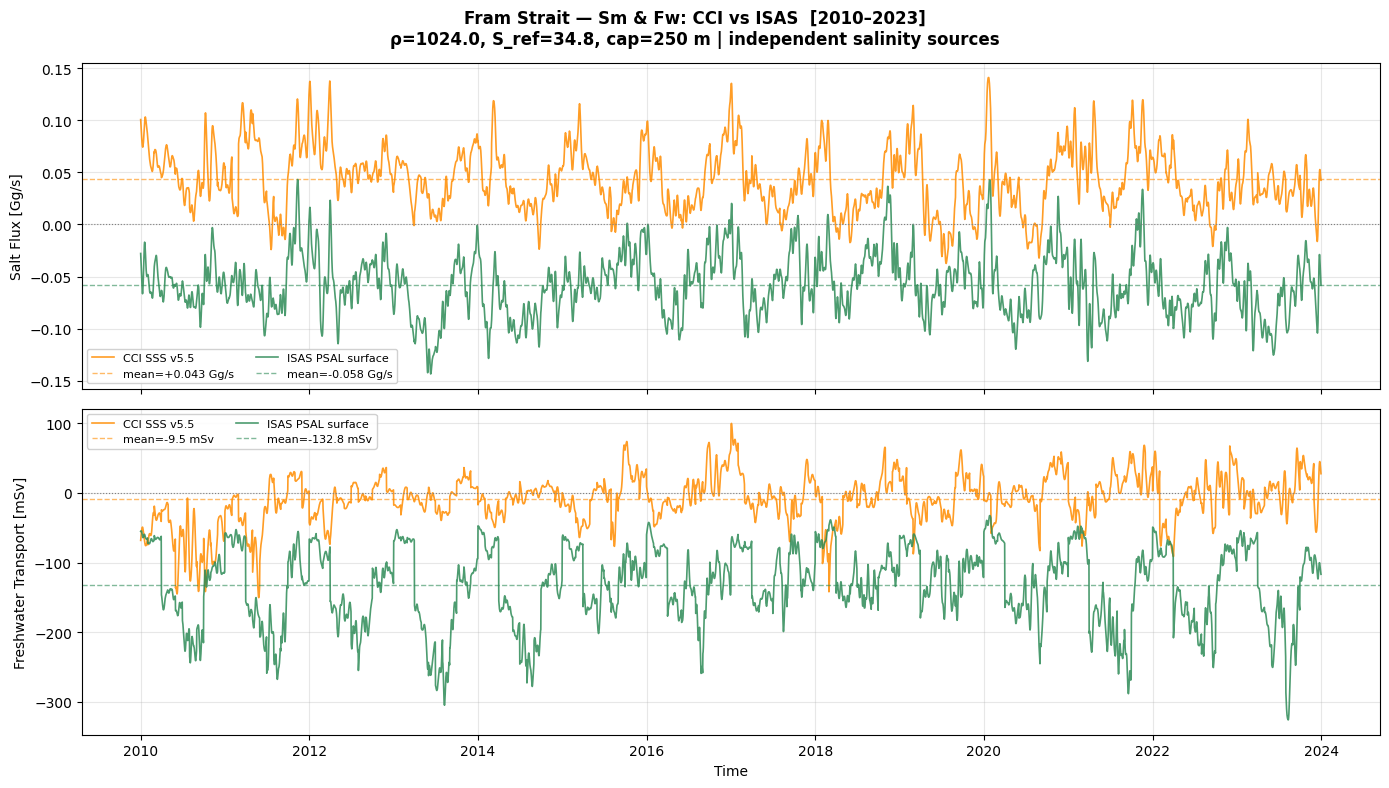

In [ ]:
# ── 6b. Sm & Fw timelines — CCI vs ISAS (independent) ──
if len(SAL_SOURCES) < 2:
    print('⚠️  Need both CCI and ISAS — skipping Sm/Fw comparison.')
else:
    fig, (ax_sm, ax_fw) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    for var, label, col in SAL_SOURCES:
        # Salt flux  [Gg/s]
        sm = salt_flux_with_salinity(ds, var, depth_cap=CAP, rho=RHO) / 1e9
        mu_sm = float(np.nanmean(sm))
        ok = np.isfinite(sm)
        ax_sm.plot(time[ok], sm[ok], color=col, lw=1.2, alpha=0.85, label=f'{label}')
        ax_sm.axhline(mu_sm, color=col, lw=1, ls='--', alpha=0.6,
                       label=f'mean={mu_sm:+.3f} Gg/s')

        # Freshwater transport  [mSv]
        fw = freshwater_transport_with_salinity(ds, var, depth_cap=CAP, s_ref=S_REF) / 1e3
        mu_fw = float(np.nanmean(fw))
        ok = np.isfinite(fw)
        ax_fw.plot(time[ok], fw[ok], color=col, lw=1.2, alpha=0.85, label=f'{label}')
        ax_fw.axhline(mu_fw, color=col, lw=1, ls='--', alpha=0.6,
                       label=f'mean={mu_fw:+.1f} mSv')

        n_ok_sm = int(np.sum(np.isfinite(sm)))
        n_ok_fw = int(np.sum(np.isfinite(fw)))
        print(f'  {label:35s}  Sm: {mu_sm:+.4f} Gg/s (N={n_ok_sm})  |  '
              f'Fw: {mu_fw:+.1f} mSv (N={n_ok_fw})')

    for ax in (ax_sm, ax_fw):
        ax.axhline(0, color='gray', lw=0.8, ls=':')
        ax.legend(fontsize=8, framealpha=0.9, ncol=2)
        ax.grid(alpha=0.3)

    ax_sm.set_ylabel('Salt Flux [Gg/s]')
    ax_fw.set_ylabel('Freshwater Transport [mSv]')
    ax_fw.set_xlabel('Time')
    fig.suptitle(f'{gate_name} — Sm & Fw: CCI vs ISAS  [{DATE_START[:4]}–{DATE_END[:4]}]\n'
                 f'ρ={RHO}, S_ref={S_REF}, cap={CAP} m | independent salinity sources',
                 fontsize=12, fontweight='bold')
    fig.tight_layout(); plt.show()

In [ ]:
# ── Diagnostic: does ISAS PSAL repeat every year or vary? ──
psal = ds['psal_isas_surface'].values   # (point, time)
time_idx = pd.to_datetime(ds['time'].values)

# Pick point 45 (mid-gate) — extract Jan 15 value for each year
pt = 45
years = sorted(set(time_idx.year))

print(f'ISAS PSAL surface at point {pt} (lon={lon[pt]:.2f}°, lat={lat[pt]:.2f}°)')
print(f'{"Year":>6}  {"Jan 15":>10}  {"Apr 15":>10}  {"Jul 15":>10}  {"Oct 15":>10}')
print('─' * 52)
for yr in years:
    vals = []
    for mo in [1, 4, 7, 10]:
        target = pd.Timestamp(yr, mo, 15)
        if target in time_idx:
            tidx = np.where(time_idx == target)[0][0]
            vals.append(f'{psal[pt, tidx]:.4f}')
        else:
            vals.append('   N/A   ')
    print(f'{yr:>6}  {"  ".join(vals)}')

# Check if all years are identical for Jan
jan_vals = []
for yr in years:
    target = pd.Timestamp(yr, 1, 15)
    if target in time_idx:
        tidx = np.where(time_idx == target)[0][0]
        jan_vals.append(psal[pt, tidx])

jan_vals = np.array(jan_vals)
if np.nanstd(jan_vals) < 1e-10:
    print(f'\n⚠️  ISAS Jan-15 values are IDENTICAL across all years → it IS a repeated climatology')
else:
    print(f'\n✅  ISAS Jan-15 values VARY across years (std = {np.nanstd(jan_vals):.6f} PSU)')

# Also check: unique values per month across all years
print(f'\nUnique ISAS values per calendar month (point {pt}):')
for mo in range(1, 13):
    mask = time_idx.month == mo
    mo_vals = psal[pt, mask]
    n_unique = len(np.unique(mo_vals[np.isfinite(mo_vals)]))
    print(f'  {MONTH_NAMES[mo-1]:>3}: {n_unique:>4} unique values out of {int(np.sum(np.isfinite(mo_vals)))} days')

ISAS PSAL surface at point 45 (lon=-9.56°, lat=80.54°)
  Year      Jan 15      Apr 15      Jul 15      Oct 15
────────────────────────────────────────────────────
  2010  33.2786  32.3836  31.0295  32.6789
  2011  33.2786  32.3836  31.0295  32.6789
  2012  33.2786  32.3836  31.0295  32.6789
  2013  33.2786  32.3836  31.0295  32.6789
  2014  33.2786  32.3836  31.0295  32.6789
  2015  33.2786  32.3836  31.0295  32.6789
  2016  33.2786  32.3836  31.0295  32.6789
  2017  33.2786  32.3836  31.0295  32.6789
  2018  33.2786  32.3836  31.0295  32.6789
  2019  33.2786  32.3836  31.0295  32.6789
  2020  33.2786  32.3836  31.0295  32.6789
  2021  33.2786  32.3836  31.0295  32.6789
  2022  33.2786  32.3836  31.0295  32.6789
  2023  33.2786  32.3836  31.0295  32.6789

✅  ISAS Jan-15 values VARY across years (std = 0.000008 PSU)

Unique ISAS values per calendar month (point 45):
  Jan:    1 unique values out of 434 days
  Feb:    1 unique values out of 395 days
  Mar:    1 unique values out of 434 d

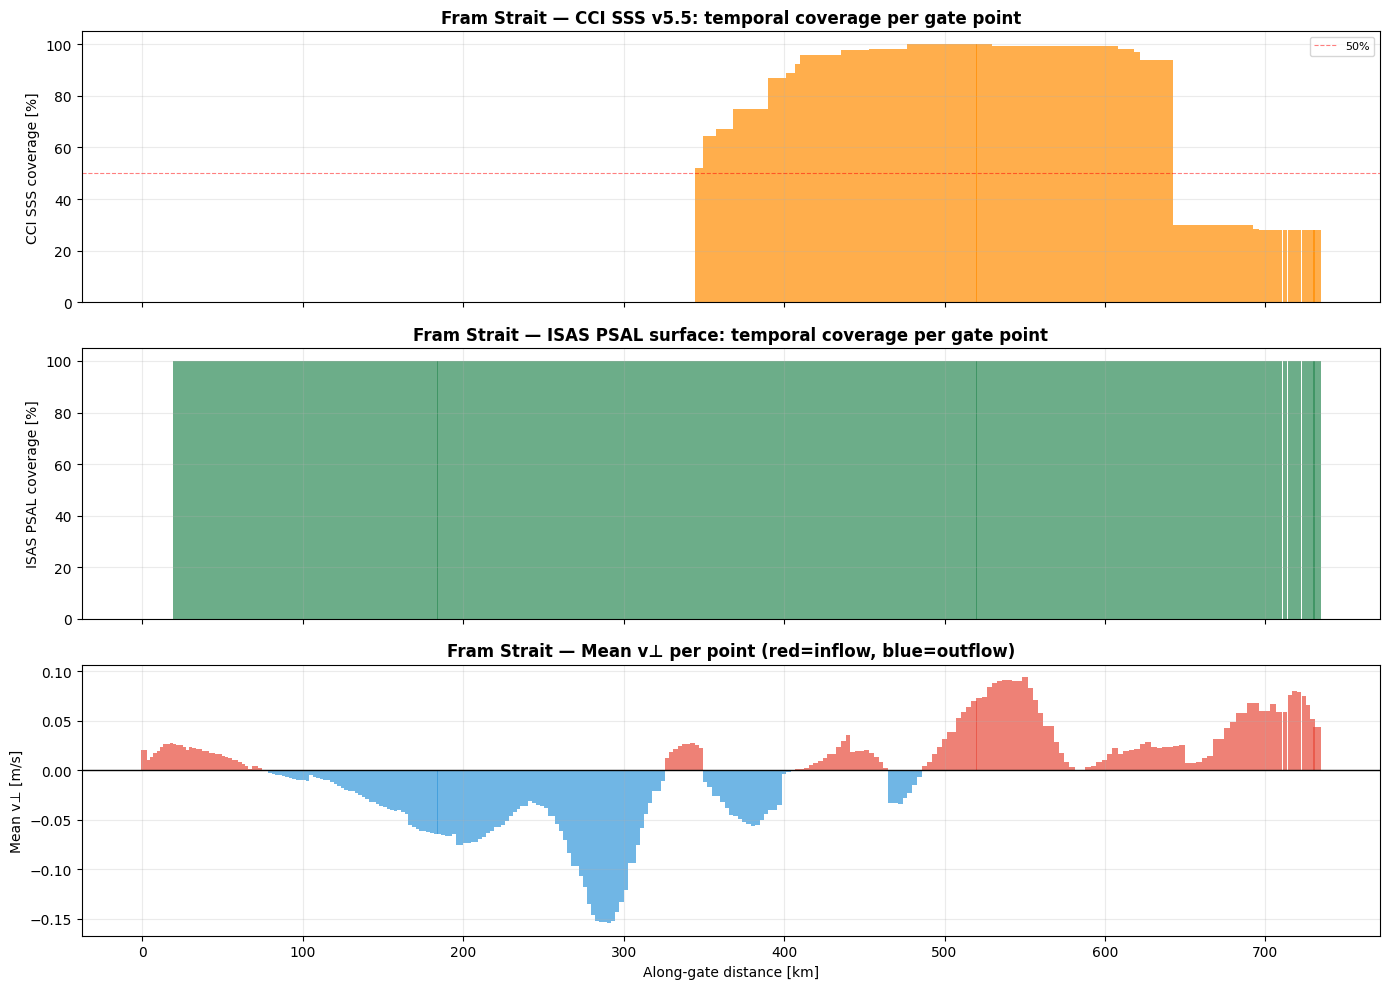


════════════════════════════════════════════════════════════════════════
  Fram Strait: CCI SSS spatial diagnosis
════════════════════════════════════════════════════════════════════════
  Total gate points      : 277
  Points with CCI data   : 125 (45%)
  Points WITHOUT CCI data: 152 (55%)
  CCI coverage range     : 346 km → 732 km
  Gate total length      : 732 km
────────────────────────────────────────────────────────────────────────
  Points WITHOUT CCI: mean v⊥ = -0.0314 m/s  (OUTFLOW)
  Points WITH CCI   : mean v⊥ = +0.0211 m/s  (INFLOW)
────────────────────────────────────────────────────────────────────────
  ⚠️  CCI misses the western (outflow) side!
      → Sm/Fw computed with CCI only sees the inflow side
      → This biases integrated Sm toward POSITIVE (inflow of salt)
      → This explains the sign flip in the CSV!
════════════════════════════════════════════════════════════════════════

  Geographic detail:
  Points WITHOUT CCI: lon = -14.36° → 1.72°
  Points WITH CCI 

In [ ]:
# ── Diagnostic: CCI SSS spatial coverage on Fram Strait ──
sss = ds['sss'].values          # (point, time)
isas = ds['psal_isas_surface'].values

# Per-point: fraction of time steps with finite SSS
cci_frac  = np.mean(np.isfinite(sss), axis=1)   # (point,)
isas_frac = np.mean(np.isfinite(isas), axis=1)

# Mean v_perp per point (to understand sign)
vp_mean_pt = np.nanmean(v_perp, axis=1)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: CCI coverage per point
axes[0].bar(x_km, cci_frac * 100, width=np.diff(x_km, append=x_km[-1]+5), 
            color='darkorange', alpha=0.7, edgecolor='none')
axes[0].set_ylabel('CCI SSS coverage [%]')
axes[0].set_title(f'{gate_name} — CCI SSS v5.5: temporal coverage per gate point', fontweight='bold')
axes[0].axhline(50, color='red', ls='--', lw=0.8, alpha=0.5, label='50%')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)

# Panel 2: ISAS coverage (should be ~100%)
axes[1].bar(x_km, isas_frac * 100, width=np.diff(x_km, append=x_km[-1]+5),
            color='seagreen', alpha=0.7, edgecolor='none')
axes[1].set_ylabel('ISAS PSAL coverage [%]')
axes[1].set_title(f'{gate_name} — ISAS PSAL surface: temporal coverage per gate point', fontweight='bold')
axes[1].grid(alpha=0.25)

# Panel 3: mean v_perp per point + annotate which side has CCI
axes[2].bar(x_km, vp_mean_pt, width=np.diff(x_km, append=x_km[-1]+5),
            color=np.where(vp_mean_pt > 0, '#E74C3C', '#3498DB'), alpha=0.7, edgecolor='none')
axes[2].axhline(0, color='black', lw=1)
axes[2].set_ylabel('Mean v⊥ [m/s]')
axes[2].set_xlabel('Along-gate distance [km]')
axes[2].set_title(f'{gate_name} — Mean v⊥ per point (red=inflow, blue=outflow)', fontweight='bold')
axes[2].grid(alpha=0.25)

fig.tight_layout(); plt.show()

# Summary stats
n_pts = len(x_km)
pts_with_cci = int(np.sum(cci_frac > 0.01))
pts_no_cci = n_pts - pts_with_cci
cci_west_edge = x_km[cci_frac > 0.01].min() if pts_with_cci > 0 else np.nan
cci_east_edge = x_km[cci_frac > 0.01].max() if pts_with_cci > 0 else np.nan

print(f'\n{"═"*72}')
print(f'  {gate_name}: CCI SSS spatial diagnosis')
print(f'{"═"*72}')
print(f'  Total gate points      : {n_pts}')
print(f'  Points with CCI data   : {pts_with_cci} ({pts_with_cci/n_pts*100:.0f}%)')
print(f'  Points WITHOUT CCI data: {pts_no_cci} ({pts_no_cci/n_pts*100:.0f}%)')
print(f'  CCI coverage range     : {cci_west_edge:.0f} km → {cci_east_edge:.0f} km')
print(f'  Gate total length      : {x_km[-1]:.0f} km')
print(f'{"─"*72}')

# Which side is missing and what does v_perp look like there?
no_cci_mask = cci_frac < 0.01
if np.any(no_cci_mask):
    vp_no_cci = vp_mean_pt[no_cci_mask]
    vp_with_cci = vp_mean_pt[~no_cci_mask]
    print(f'  Points WITHOUT CCI: mean v⊥ = {np.nanmean(vp_no_cci):+.4f} m/s  '
          f'({"OUTFLOW" if np.nanmean(vp_no_cci) < 0 else "INFLOW"})')
    print(f'  Points WITH CCI   : mean v⊥ = {np.nanmean(vp_with_cci):+.4f} m/s  '
          f'({"OUTFLOW" if np.nanmean(vp_with_cci) < 0 else "INFLOW"})')
    print(f'{"─"*72}')
    print(f'  ⚠️  CCI misses the {"western (outflow)" if np.nanmean(vp_no_cci) < 0 else "eastern"} side!')
    print(f'      → Sm/Fw computed with CCI only sees the '
          f'{"inflow" if np.nanmean(vp_with_cci) > 0 else "outflow"} side')
    print(f'      → This biases integrated Sm toward POSITIVE (inflow of salt)')
    print(f'      → This explains the sign flip in the CSV!')
print(f'{"═"*72}')

# Lon/lat of the boundary
print(f'\n  Geographic detail:')
print(f'  Points WITHOUT CCI: lon = {lon[no_cci_mask].min():.2f}° → {lon[no_cci_mask].max():.2f}°')
print(f'  Points WITH CCI   : lon = {lon[~no_cci_mask].min():.2f}° → {lon[~no_cci_mask].max():.2f}°')